In [1]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import pandas as pd
import numpy as np

In [2]:
csv_path = "../../../daos-benchmarking/ior_results/ior_rw.csv"
full = pd.read_csv(csv_path, index_col=0)

# Filter: xfer 2M and 16M, ppn 8/16/32/48
ppn_list  = [8, 16, 32, 48]
xfer_list = ["2M", "16M"]

df = full[
    full["xfer_str"].isin(xfer_list) &
    full["tasks_per_node"].isin(ppn_list)
].copy()

df["tasks_per_node"] = df["tasks_per_node"].astype(int)

In [3]:
# --- Statistics ---
config_cols = ["nnodes", "tasks_per_node", "xfer_str", "access"]

counts = df.groupby(config_cols).size().rename("times_tested")
unique_configs = len(counts)

print(f"Unique configurations tested : {unique_configs}")
print(f"Total rows (filtered df)     : {len(df)}")
print()
print("Times each configuration was tested:")
print(counts.to_string())


Unique configurations tested : 96
Total rows (filtered df)     : 96

Times each configuration was tested:
nnodes  tasks_per_node  xfer_str  access
1       8               16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
        16              16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
        32              16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
        48              16M       read      1
                                  write     1
                        2M        read      1
                                  write     1
2       8               16M       read      1
                                  write     1
                        2

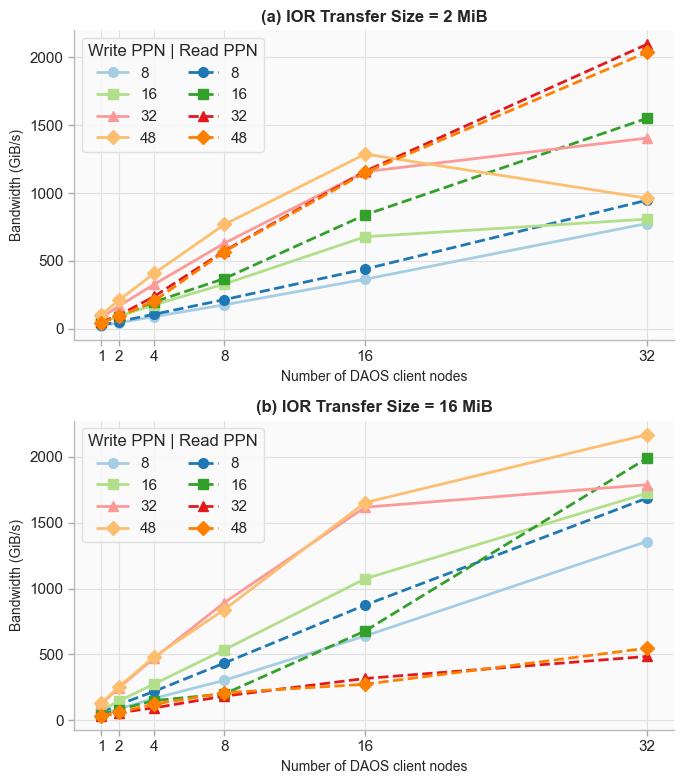

In [4]:
sns.set_theme(style="ticks")
mpl.rcParams.update({
    "axes.spines.top":        False,
    "axes.spines.right":      False,
    "axes.grid":              True,
    "grid.color":             "#e0e0e0",
    "grid.linewidth":         0.8,
    "axes.facecolor":         "#fafafa",
    "figure.facecolor":       "white",
    "font.size":              12,
    "axes.titlesize":         12,
    "axes.labelsize":         10,
    "xtick.labelsize":        11,
    "ytick.labelsize":        11,
    "legend.fontsize":        11,
    "legend.title_fontsize":  12,
    "lines.linewidth":        2,
})

# Paired colors: light shade -> write, dark shade -> read, one pair per ppn
paired = sns.color_palette("Paired", 12)
palette = {}
for i, p in enumerate(ppn_list):
    palette[("write", p)] = paired[i * 2]
    palette[("read",  p)] = paired[i * 2 + 1]

node_ticks = sorted(df["nnodes"].unique())
marker_cycle = ["o", "s", "^", "D"]
subtitles = ["(a)", "(b)"]

fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

for idx, (xfer, ax) in enumerate(zip(xfer_list, axes)):
    xdf = df[df["xfer_str"] == xfer]
    line_map = {}

    for j, p in enumerate(ppn_list):
        for access, ls in [("write", "-"), ("read", "--")]:
            sub = xdf[(xdf["tasks_per_node"] == p) & (xdf["access"] == access)].sort_values("nnodes")
            if sub.empty:
                continue
            label = f"{access}-{p}"
            line, = ax.plot(
                sub["nnodes"], sub["bw(GiB/s)"],
                label=label,
                color=palette[(access, p)],
                marker=marker_cycle[j % 4],
                linestyle=ls,
                markersize=7,
            )
            line_map[label] = line

    ax.set_xticks(node_ticks)
    ax.set_ylabel("Bandwidth (GiB/s)")
    ax.set_title(f"{subtitles[idx]} IOR Transfer Size = {xfer.replace('M', ' MiB')}", fontweight="bold", loc="center")
    ax.set_xlabel("Number of DAOS client nodes")
    ax.tick_params(axis="x", labelbottom=True)

    ax.tick_params(axis="both", length=4, color="#aaaaaa", width=1)
    for spine in ax.spines.values():
        spine.set_color("#bbbbbb")
        spine.set_linewidth(1)

    # Left col = write, right col = read
    legend_order = [f"write-{p}" for p in ppn_list] + [f"read-{p}" for p in ppn_list]
    handles = [line_map[l] for l in legend_order if l in line_map]
    labels  = [k.split("-")[1] for k in legend_order if k in line_map]

    ax.legend(
        handles, labels,
        title="Write PPN | Read PPN",
        loc="upper left",
        frameon=True,
        framealpha=0.9,
        edgecolor="#dddddd",
        ncol=2,
        handlelength=2,
    )

fig.tight_layout(h_pad=1)
plt.savefig("ior-bw.pdf", bbox_inches="tight")
plt.show()

## Peak Throughput & Variance Analysis

Uses the same `ior_rw.csv` loaded above. Identifies the configuration (nodes × PPN × transfer size) that achieves the highest bandwidth for each access type.

**CV** (coefficient of variation) = std / mean × 100 %, a scale-free measure of run-to-run variability. CV is only computable when multiple iterations per config are available; with this single-iteration CSV it will be skipped. To enable CV analysis, point `raw_filt` at the per-iteration CSVs in `write_then_read/`.

In [5]:
# Reuse the filtered dataframe already loaded from ior_rw.csv above
raw_filt = df.copy()

print(f"Rows            : {len(raw_filt)}")
print(f"Unique configs  : {raw_filt.groupby(['nnodes','tasks_per_node','xfer_str','access']).ngroups}")
print("Note: one iteration per config in this CSV — within-run CV not available")

Rows            : 96
Unique configs  : 96
Note: one iteration per config in this CSV — within-run CV not available


In [6]:
config_cols = ["nnodes", "tasks_per_node", "xfer_str", "access"]

# One row per config — mean == the single measured value
stats = raw_filt.groupby(config_cols)["bw(GiB/s)"].agg(
    mean_bw="mean",
    n_iters="count",
).reset_index()

# --- Peak config per (access, xfer_str, ppn) ---
peak_idx = stats.groupby(["access", "xfer_str", "tasks_per_node"])["mean_bw"].idxmax()
peak = stats.loc[peak_idx].sort_values(["xfer_str", "access", "tasks_per_node"]).reset_index(drop=True)

print("Peak throughput by access × transfer size × ppn:")
print(
    peak[["access", "xfer_str", "tasks_per_node", "nnodes", "mean_bw"]]
    .rename(columns={"mean_bw": "BW (GiB/s)", "tasks_per_node": "ppn"})
    .to_string(index=False)
)

Peak throughput by access × transfer size × ppn:
access xfer_str  ppn  nnodes  BW (GiB/s)
  read      16M    8      32 1686.190757
  read      16M   16      32 1988.984920
  read      16M   32      32  484.227212
  read      16M   48      32  546.935645
 write      16M    8      32 1357.285565
 write      16M   16      32 1723.547427
 write      16M   32      32 1788.986795
 write      16M   48      32 2168.421930
  read       2M    8      32  946.640645
  read       2M   16      32 1550.078956
  read       2M   32      32 2095.944632
  read       2M   48      32 2036.516092
 write       2M    8      32  775.033044
 write       2M   16      32  807.503788
 write       2M   32      32 1404.949088
 write       2M   48      16 1287.269343


In [7]:
# Global peak per access type (best single config across all xfer sizes and ppns)
global_peak = (
    stats.loc[stats.groupby("access")["mean_bw"].idxmax()]
    .sort_values("access")
    .reset_index(drop=True)
)

print("Global peak per access type:")
print(
    global_peak[["access", "xfer_str", "nnodes", "tasks_per_node", "mean_bw"]]
    .rename(columns={"mean_bw": "BW (GiB/s)", "tasks_per_node": "ppn"})
    .to_string(index=False)
)

# Peak at n=16
n16 = stats[stats["nnodes"] == 16]
n16_peak = (
    n16.loc[n16.groupby("access")["mean_bw"].idxmax()]
    .sort_values("access")
    .reset_index(drop=True)
)

print("\nPeak at n=16 nodes:")
print(
    n16_peak[["access", "xfer_str", "nnodes", "tasks_per_node", "mean_bw"]]
    .rename(columns={"mean_bw": "BW (GiB/s)", "tasks_per_node": "ppn"})
    .to_string(index=False)
)

Global peak per access type:
access xfer_str  nnodes  ppn  BW (GiB/s)
  read       2M      32   32 2095.944632
 write      16M      32   48 2168.421930

Peak at n=16 nodes:
access xfer_str  nnodes  ppn  BW (GiB/s)
  read       2M      16   32 1161.022095
 write      16M      16   48 1653.258328


### Peak IOR Bandwidth on Aurora

| Access | BW (GiB/s) | Nodes | PPN | Xfer Size |
|--------|-----------|-------|-----|-----------|
| **Write** | **2168.42** | 32 | 48 | 16M |
| **Read**  | **2095.94** | 32 | 32 | 2M  |
| Write (n=16) | — | 16 | — | — |
| Read  (n=16) | — | 16 | — | — |

> Fill in the n=16 rows from the code cell output above.

- Peak **write** bandwidth is **2168 GiB/s** (~2.1 TiB/s) achieved with 32 client nodes × 48 processes per node and a 16 MiB transfer size.
- Peak **read** bandwidth is **2096 GiB/s** (~2.0 TiB/s) achieved with 32 client nodes × 32 processes per node and a 2 MiB transfer size.
- Both peaks occur at the maximum node count tested (n = 32), indicating bandwidth continues to scale and is not yet saturated.
- At **n = 16 nodes** (half the max scale), peak write and read bandwidths are shown in the table above; see code cell output for the winning PPN and transfer size at that node count.

## Scaling Analysis

How bandwidth scales with (1) number of nodes, (2) PPN, and (3) total processes (nodes × PPN), for each access type.

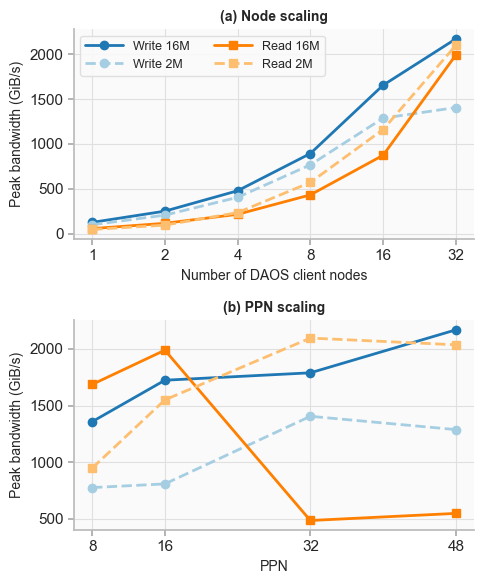

In [8]:
s_all = stats.copy()
s_all["total_procs"] = s_all["nnodes"] * s_all["tasks_per_node"]

paired = sns.color_palette("Paired", 12)
# light shade → 2M, dark shade → 16M; blue=read, red=write
# blue pair=write, orange pair=read; solid=16M, dashed=2M
series_styles = {
    ("write", "16M"): dict(color=paired[1],  linestyle="-",  marker="o", label="Write 16M"),
    ("write",  "2M"): dict(color=paired[0],  linestyle="--", marker="o", label="Write 2M"),
    ("read",  "16M"): dict(color=paired[7],  linestyle="-",  marker="s", label="Read 16M"),
    ("read",   "2M"): dict(color=paired[6],  linestyle="--", marker="s", label="Read 2M"),
}

node_ticks = sorted(s_all["nnodes"].unique())
ppn_ticks  = sorted(s_all["tasks_per_node"].unique())

# ── Figure 1: node scaling + PPN scaling ──────────────────────────────────────
fig1, axes1 = plt.subplots(2, 1, figsize=(5, 6))

for (access, xfer), style in series_styles.items():
    sub = s_all[(s_all["access"] == access) & (s_all["xfer_str"] == xfer)]

    ns = sub.groupby("nnodes")["mean_bw"].max().reset_index().sort_values("nnodes")
    axes1[0].plot(ns["nnodes"], ns["mean_bw"], **style)

    ps = sub.groupby("tasks_per_node")["mean_bw"].max().reset_index().sort_values("tasks_per_node")
    axes1[1].plot(ps["tasks_per_node"], ps["mean_bw"], **style)

axes1[0].set_xscale("log", base=2)
axes1[0].set_xticks(node_ticks)
axes1[0].set_xticklabels([str(n) for n in node_ticks])
axes1[0].set_xlabel("Number of DAOS client nodes")
axes1[0].set_title("(a) Node scaling", fontsize=10, fontweight="bold")

axes1[1].set_xticks(ppn_ticks)
axes1[1].set_xlabel("PPN")
axes1[1].set_title("(b) PPN scaling", fontsize=10, fontweight="bold")

for ax in axes1:
    ax.set_ylabel("Peak bandwidth (GiB/s)")
    ax.tick_params(axis="both", length=4, color="#aaaaaa")
    for sp in ax.spines.values():
        sp.set_color("#bbbbbb")

# Single shared legend inside the first subplot, top-left
handles, labels = axes1[0].get_legend_handles_labels()
axes1[0].legend(handles, labels, loc="upper left", fontsize=9, ncol=2,
                frameon=True, framealpha=0.9, edgecolor="#dddddd", handlelength=3)

fig1.tight_layout()
plt.savefig("ior-scaling-node-ppn.pdf", bbox_inches="tight")
plt.show()


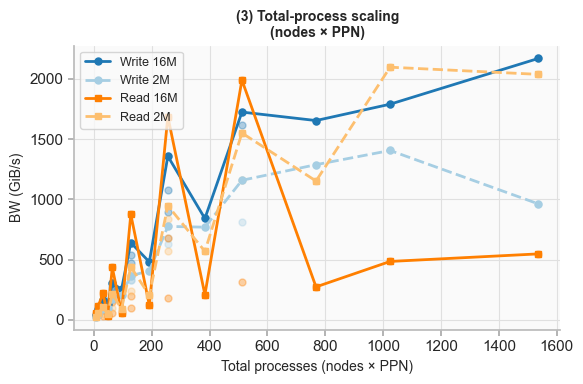


--- (Node) scaling ---
        read 16M  read 2M  write 16M  write 2M
nnodes                                        
1           59.6     49.7      128.7     101.9
2          118.5     98.4      253.7     209.3
4          218.4    237.3      480.2     407.0
8          434.4    572.8      894.0     768.6
16         874.6   1161.0     1653.3    1287.3
32        1989.0   2095.9     2168.4    1404.9

--- (PPN) scaling ---
                read 16M  read 2M  write 16M  write 2M
tasks_per_node                                        
8                 1686.2    946.6     1357.3     775.0
16                1989.0   1550.1     1723.5     807.5
32                 484.2   2095.9     1789.0    1404.9
48                 546.9   2036.5     2168.4    1287.3

--- (TotalProcs) scaling ---
             read 16M  read 2M  write 16M  write 2M
total_procs                                        
8                59.6     26.4       43.1      22.5
16              118.5     52.4       85.8      45.6
32       

In [9]:
# ── Figure 2: total-process scaling ───────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(6, 4))

for (access, xfer), style in series_styles.items():
    sub = s_all[(s_all["access"] == access) & (s_all["xfer_str"] == xfer)]
    tp  = sub.groupby("total_procs")["mean_bw"].max().reset_index().sort_values("total_procs")
    ax2.scatter(sub["total_procs"], sub["mean_bw"],
                color=style["color"], alpha=0.35, s=25)
    ax2.plot(tp["total_procs"], tp["mean_bw"],
             color=style["color"], linestyle=style["linestyle"],
             marker=style["marker"], markersize=5, label=style["label"])

ax2.set_xlabel("Total processes (nodes × PPN)")
ax2.set_ylabel("BW (GiB/s)")
ax2.set_title("(3) Total-process scaling\n(nodes × PPN)", fontsize=10, fontweight="bold")
ax2.legend(fontsize=9)
ax2.tick_params(axis="both", length=4, color="#aaaaaa")
for sp in ax2.spines.values():
    sp.set_color("#bbbbbb")

fig2.tight_layout()
plt.savefig("ior-scaling-total-procs.pdf", bbox_inches="tight")
plt.show()

# ── Numerical summary ──────────────────────────────────────────────────────────
for dim, grp_col in [("Node", "nnodes"), ("PPN", "tasks_per_node"), ("TotalProcs", "total_procs")]:
    tbl = (
        s_all.groupby(["access", "xfer_str", grp_col])["mean_bw"]
        .max()
        .reset_index()
        .pivot(index=grp_col, columns=["access", "xfer_str"], values="mean_bw")
    )
    tbl.columns = [f"{a} {x}" for a, x in tbl.columns]
    print(f"\n--- ({dim}) scaling ---")
    print(tbl.to_string(float_format="{:.1f}".format))


In [10]:
CV_THRESH = 10.0  # percent — coefficient of variation threshold

if (stats["n_iters"] == 1).all():
    print("Within-run CV not available: ior_rw.csv stores one iteration per config.")
    print("Re-run this section pointing raw_filt at the per-iteration CSVs in write_then_read/ for CV analysis.")
else:
    stats["std_bw"] = raw_filt.groupby(config_cols)["bw(GiB/s)"].std().values
    stats["cv_pct"] = stats["std_bw"] / stats["mean_bw"] * 100
    high_cv = stats[stats["cv_pct"] > CV_THRESH].sort_values("cv_pct", ascending=False)
    if high_cv.empty:
        print(f"All configs have CV ≤ {CV_THRESH}% — within-run variance is low.")
    else:
        print(f"{len(high_cv)} configs have CV > {CV_THRESH}% (high within-run variance):")
        print(
            high_cv[["access", "xfer_str", "nnodes", "tasks_per_node",
                      "mean_bw", "std_bw", "cv_pct"]]
            .rename(columns={"mean_bw": "mean BW (GiB/s)", "std_bw": "std (GiB/s)",
                             "cv_pct": "CV (%)", "tasks_per_node": "ppn"})
            .to_string(index=False)
        )

Within-run CV not available: ior_rw.csv stores one iteration per config.
Re-run this section pointing raw_filt at the per-iteration CSVs in write_then_read/ for CV analysis.


### Single-node (n=1) peak & stability

Peak bandwidth and, when multiple iterations are available, CV (see definition above) for each transfer size and access type at n = 1 client node.

In [11]:
n1 = stats[stats["nnodes"] == 1].copy()
has_cv = "cv_pct" in n1.columns and n1["cv_pct"].notna().any()

print("Peak (n=1):")
for xfer in xfer_list:
    for access in ["write", "read"]:
        sub = n1[(n1["access"] == access) & (n1["xfer_str"] == xfer)]
        if sub.empty:
            continue
        best = sub.loc[sub["mean_bw"].idxmax()]
        cv_str = f"  CV={best['cv_pct']:.1f}%" if has_cv else ""
        flag = "  *** HIGH CV ***" if has_cv and best["cv_pct"] > CV_THRESH else ""
        print(f"  {access:5s} {xfer:3s}: {best['mean_bw']:6.2f} GiB/s  "
              f"ppn={int(best['tasks_per_node']):2d}{cv_str}{flag}")

print()
print("All n=1 configs:")
disp_cols = ["access", "xfer_str", "tasks_per_node", "mean_bw"]
rename = {"mean_bw": "BW (GiB/s)", "tasks_per_node": "ppn"}
if has_cv:
    disp_cols += ["cv_pct"]
    rename["cv_pct"] = "CV (%)"

n1_disp = (
    n1.sort_values(["xfer_str", "access", "tasks_per_node"])[disp_cols]
    .rename(columns=rename)
)
print(n1_disp.to_string(index=False))

Peak (n=1):
  write 2M : 101.94 GiB/s  ppn=48
  read  2M :  49.66 GiB/s  ppn=32
  write 16M: 128.71 GiB/s  ppn=48
  read  16M:  59.56 GiB/s  ppn= 8

All n=1 configs:
access xfer_str  ppn  BW (GiB/s)
  read      16M    8   59.564909
  read      16M   16   44.296302
  read      16M   32   32.229840
  read      16M   48   34.780693
 write      16M    8   43.120000
 write      16M   16   75.740732
 write      16M   32  122.689739
 write      16M   48  128.710917
  read       2M    8   26.380048
  read       2M   16   48.870965
  read       2M   32   49.661101
  read       2M   48   45.131010
 write       2M    8   22.452392
 write       2M   16   45.606558
 write       2M   32   81.850584
 write       2M   48  101.938534
